# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [72]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0

#### **1.2** Import necessary libraries

In [73]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [74]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [75]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis*
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function**

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [76]:
# define a function to load json file to a dataframe
# Function to load the recipe JSON data into a pandas DataFrame
def load_json_dataframe(file_path):
    """
    Loads raw JSON data from the specified path and converts it to a DataFrame.
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        return pd.DataFrame(data)
    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
        return None

##### **2.1.2** **Execute the *load_json_dataframe* function**

In [77]:
# read the json file by giving the file path and create a dataframe
file_path = 'ingredient_and_quantity.json'
df = load_json_dataframe(file_path)

##### **2.1.3** **Describe the dataframe**

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [78]:
# display first five rows of the dataframe - df
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [79]:
# print the dimensions of dataframe - df
print(f"Dimensions of the dataframe: {df.shape}")

Dimensions of the dataframe: (285, 2)


In [80]:
# print the information of the dataframe
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation*
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [81]:
# split the input and pos into input_tokens and pos_tokens in the dataframe
# Tokenizing the raw text into lists of individual words and their corresponding labels
df['input_tokens'] = df['input'].apply(lambda x: x.split())
df['pos_tokens'] = df['pos'].apply(lambda x: x.split())
# Tokenize input
# Tokenize POS

In [82]:
# display first five rows of the dataframe - df
df.head()


,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [83]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
# Calculating the number of tokens in both the input and the labels to ensure they match
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

In [84]:
# check for the equality of input_length and pos_length in the dataframe
mismatched_data = df[df['input_length'] != df['pos_length']]

# Printing the result of the validation
print(f"Total number of mismatched rows: {len(mismatched_data)}")


Total number of mismatched rows: 5


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [85]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
# Function to find all unique labels used in the dataset
def unique_labels(tokens_series):
    unique_set = set()
    for labels in tokens_series:
        unique_set.update(labels)
    return sorted(list(unique_set))

# Running the function to see the current labels
print("Current unique labels in data:", unique_labels(df['pos_tokens']))

Current unique labels in data: ['ingredient', 'quantity', 'unit']


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>
The primary issue is the length mismatch between input_tokens and pos_tokens in some rows. In CRF models, every input word must have exactly one corresponding label. We must remove these inconsistent rows to ensure the model trains correctly

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [86]:
# drop the irrelevant recipe data
# Dropping rows where lengths are not equal to maintain data integrity
df = df[df['input_length'] == df['pos_length']].reset_index(drop=True)
print(f"Dataset size after cleaning: {df.shape}")

Dataset size after cleaning: (280, 6)


##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [87]:
# update the input and pos length in input_length and pos_length
# Refreshing length columns after dropping rows
df['input_length'] = df['input_tokens'].apply(len)
df['pos_length'] = df['pos_tokens'].apply(len)

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [88]:
# validate the input length and pos length as input_length and pos_length
# Final confirmation that all rows are now aligned
print("Remaining mismatches:", len(df[df['input_length'] != df['pos_length']]))

Remaining mismatches: 0


## **3** Train Validation Split (70 train - 30 val)

#### **3.1** *Perform train and validation split ratio*
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio**

In [89]:
# split the dataset into training and validation sets
# Splitting the dataset into training (70%) and validation (30%) sets
train_df, val_df = train_test_split(df, test_size=0.30, random_state=42)

###### **3.1.2** **Print the first five rows of train_df and val_df**

In [90]:
# print the first five rows of train_df
# Displaying the first five rows of the training dataframe
train_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length
175,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
55,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
109,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
213,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, qua

In [91]:
# print the first five rows of the val_df
# Displaying the first five rows of the validation dataframe
val_df.head()

,input,pos,input_tokens,pos_tokens,input_length,pos_length
33,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
108,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
240,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
259,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient i

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length**

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [92]:
# extract the training and validation sets by taking input_tokens and pos_tokens
# Extracting the input tokens and labels as lists for model training
X_train = train_df['input_tokens'].tolist()
y_train = train_df['pos_tokens'].tolist()

X_val = val_df['input_tokens'].tolist()
y_val = val_df['pos_tokens'].tolist()

In [93]:
# validate the shape of training and validation samples
# Printing lengths to confirm the split and consistency
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 196
Validation samples: 84


###### **3.1.4** **Display the number of unique labels present in y_train**

In [94]:
# Display the number of unique labels present in y_train
# Flattening the label list to count unique entities in the training set
train_labels_flat = [label for sublist in y_train for label in sublist]
unique_labels_count = Counter(train_labels_flat)

print("Unique labels and their counts in the training set:")
print(unique_labels_count)

Unique labels and their counts in the training set:
Counter({'ingredient': 5323, 'quantity': 980, 'unit': 811})


## **4** Exploratory Recipe Data Analysis on Training Dataset

#### **4.1** *Flatten the lists for input_tokens & pos_tokens*

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [95]:
# flatten the list for nested_list (input_tokens, pos_tokens)
# Function to convert a nested list (list of lists) into a single flat list
def flatten_list(nested_list):
    """Flattens a list of lists into a single list of elements."""
    return [item for sublist in nested_list for item in sublist]

In [96]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique*

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [97]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
# call the flatten_list and apply it on input_tokens and pos_tokens
# validate their length and display first 10 records having input and pos tokens
# Function to extract tokens, flatten them, and perform basic validation
def extract_and_validate_tokens(dataframe, name):
    # Flattening the token and label lists
    tokens = flatten_list(dataframe['input_tokens'].tolist())
    tags = flatten_list(dataframe['pos_tokens'].tolist())

    # Validating that lengths match
    print(f"--- {name} Dataset Validation ---")
    print(f"Total tokens: {len(tokens)}")
    print(f"Total POS tags: {len(tags)}")

    if len(tokens) == len(tags):
        print("Validation Successful: Token and Tag lengths match.")
    else:
        print("Validation Failed: Mismatch in lengths.")

    # Showing the first 10 records as a sample
    print("\nFirst 10 records (Token -> Tag):")
    for i in range(10):
        print(f"{tokens[i]} -> {tags[i]}")

    return tokens, tags

In [98]:
# extract the tokens and its pos tags
# Extracting and validating tokens from the training set
train_tokens, train_tags = extract_and_validate_tokens(train_df, dataset_name)

--- Training Dataset Validation ---
Total tokens: 7114
Total POS tags: 7114
Validation Successful: Token and Tag lengths match.

First 10 records (Token -> Tag):
250 -> quantity
grams -> unit
Okra -> ingredient
Oil -> ingredient
1 -> quantity
Onion -> ingredient
finely -> ingredient
chopped -> ingredient
Tomato -> ingredient
Grated -> ingredient


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)*

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [99]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays
# Function to group tokens by their label type (ingredient, unit, quantity)
def categorize_tokens(tokens, tags):
    ingredients = []
    units = []
    quantities = []

    for token, tag in zip(tokens, tags):
        if tag == 'ingredient':
            ingredients.append(token.lower())
        elif tag == 'unit':
            units.append(token.lower())
        elif tag == 'quantity':
            quantities.append(token.lower())

    return ingredients, units, quantities


In [100]:
#  call the function to categorise the labels into respective list
# Categorising the flattened training data
train_ingredients, train_units, train_quantities = categorize_tokens(train_tokens, train_tags)

print(f"Total Ingredients: {len(train_ingredients)}")
print(f"Total Units: {len(train_units)}")
print(f"Total Quantities: {len(train_quantities)}")

Total Ingredients: 5323
Total Units: 811
Total Quantities: 980


#### **4.4** *Top 10 Most Frequent Items*

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [101]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items
# Function to retrieve the 10 most common items in a list
def get_top_frequent_items(item_list, label_name, name):
    counts = Counter(item_list)
    top_items = counts.most_common(10)

    print(f"Top 10 {label_name}s in {name} dataset:")
    for item, freq in top_items:
        print(f"{item}: {freq}")

    return top_items

In [102]:
# get the top ingredients which are frequently seen in the recipe
# Finding most frequent ingredients
top_train_ingredients = get_top_frequent_items(train_ingredients, "Ingredient", dataset_name)

Top 10 Ingredients in Training dataset:
powder: 192
salt: 123
leaves: 120
oil: 111
seeds: 111
red: 110
green: 104
chilli: 96
coriander: 93
chopped: 84


In [103]:
# get the top units which are frequently seen in the recipe
# Finding most frequent units
top_train_units = get_top_frequent_items(train_units, "Unit", dataset_name)

Top 10 Units in Training dataset:
teaspoon: 165
cup: 136
tablespoon: 100
grams: 63
tablespoons: 62
inch: 52
cups: 50
sprig: 42
cloves: 39
teaspoons: 39


#### **4.5** *Plot Top 10 most frequent items*




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [104]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
# Function to visualize the frequency distribution using Seaborn
def plot_top_items(top_items, label_name, name):
    items, counts = zip(*top_items)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(items), palette='viridis')
    plt.title(f"Top 10 Most Frequent {label_name}s ({name})")
    plt.xlabel("Frequency")
    plt.ylabel(label_name)
    plt.tight_layout()
    plt.show()

#### **4.6** *Perform EDA analysis*

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



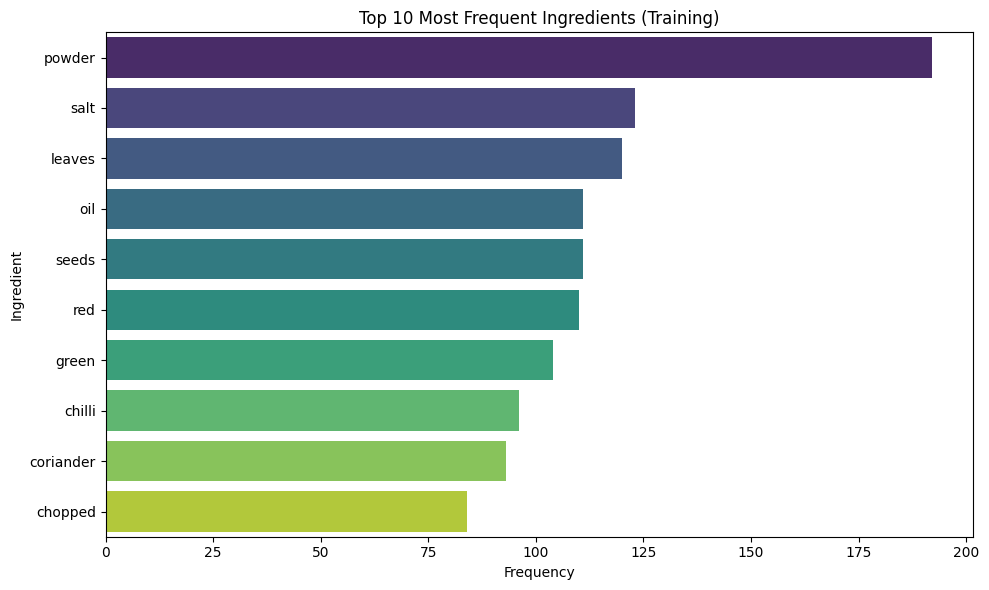

In [105]:
# plot the top frequent ingredients in training data
# Visualizing top ingredients
plot_top_items(top_train_ingredients, "Ingredient", dataset_name)

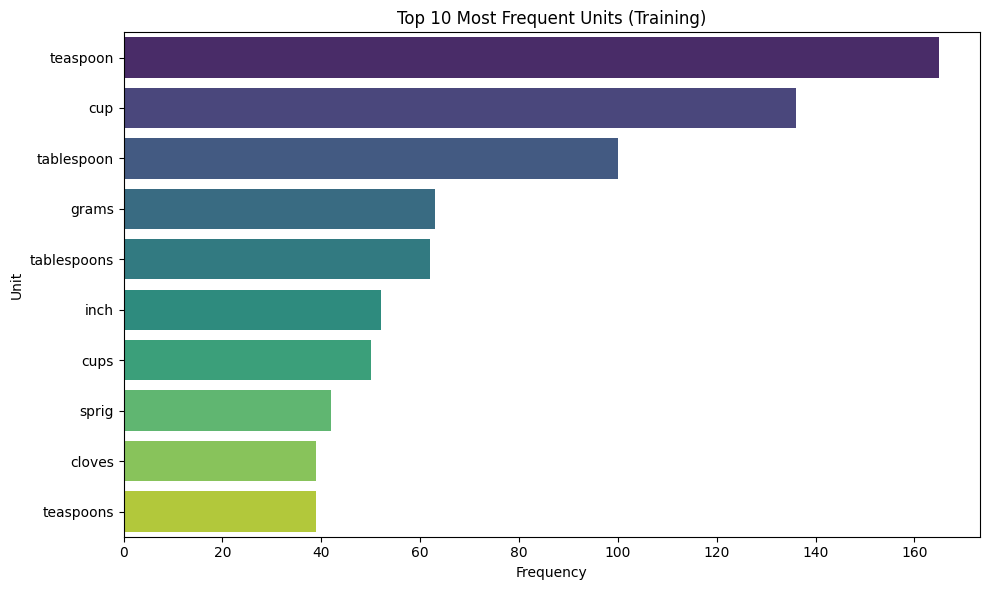

In [106]:
# plot the top frequent units in training data
# Visualizing top units
plot_top_items(top_train_units, "Unit", dataset_name)

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)*
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [107]:
# initialise the dataset_name
# Setting the dataset identifier for the validation phase
dataset_name = 'Validation'

In [108]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
# Step 1: Extract and validate tokens from the validation dataframe
val_tokens, val_tags = extract_and_validate_tokens(val_df, dataset_name)

# Step 2: Categorise the tokens into ingredients, units, and quantities
val_ingredients, val_units, val_quantities = categorize_tokens(val_tokens, val_tags)

# Step 3: Get the top 10 most frequent ingredients in the validation set
top_val_ingredients = get_top_frequent_items(val_ingredients, "Ingredient", dataset_name)

# Step 4: Get the top 10 most frequent units in the validation set
top_val_units = get_top_frequent_items(val_units, "Unit", dataset_name)

--- Validation Dataset Validation ---
Total tokens: 2876
Total POS tags: 2876
Validation Successful: Token and Tag lengths match.

First 10 records (Token -> Tag):
1 -> quantity
cup -> unit
Ada -> ingredient
2 -> quantity
liter -> unit
Milk -> ingredient
3/4 -> quantity
Sugar -> ingredient
tablespoon -> unit
Ghee -> ingredient
Top 10 Ingredients in Validation dataset:
powder: 79
salt: 57
oil: 54
red: 52
leaves: 52
seeds: 50
chilli: 41
green: 37
garlic: 36
coriander: 33
Top 10 Units in Validation dataset:
teaspoon: 59
cup: 57
tablespoon: 32
tablespoons: 32
cups: 24
sprig: 22
inch: 20
grams: 19
teaspoons: 18
cloves: 16


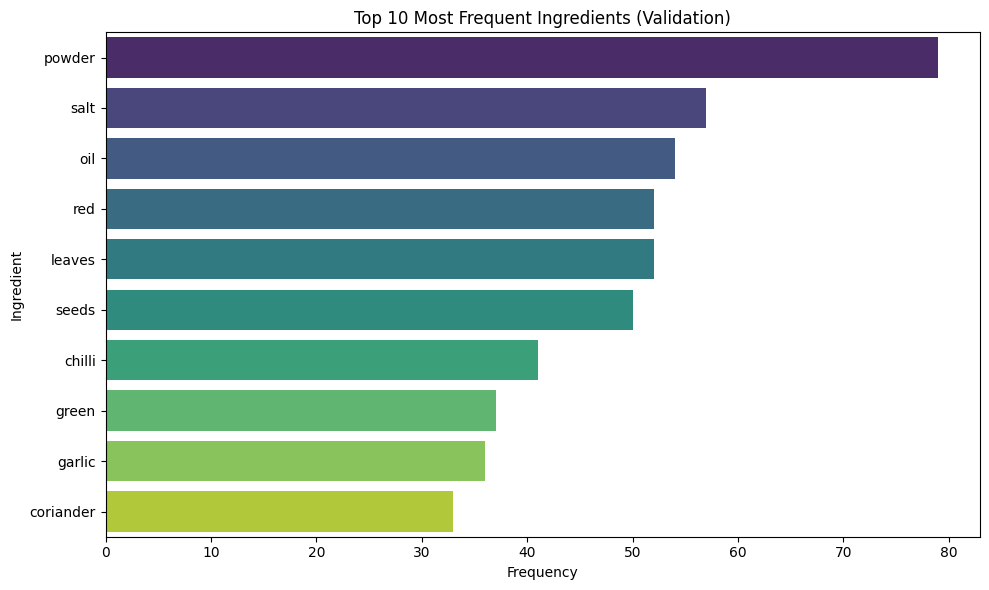

In [109]:
# plot the top frequent ingredients in validation data
# Visualizing the top 10 ingredients in the validation dataset
plot_top_items(top_val_ingredients, "Ingredient", dataset_name)

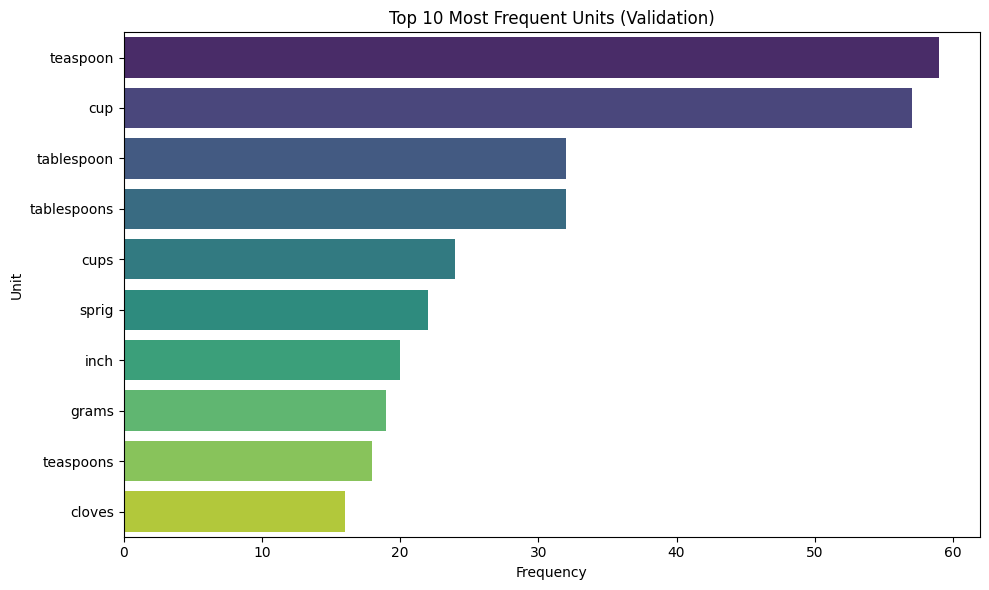

In [110]:
# plot the top frequent units in training data
# Visualizing the top 10 units in the validation dataset
plot_top_items(top_val_units, "Unit", dataset_name)

## **6** Feature Extraction For CRF Model

### **6.1** *Define a feature functions to take each token from recipe*
Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals**

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [111]:
# define unit and quantity keywords along with quantity pattern
# Defining sets for specific keywords to aid the model in identifying entities
unit_keywords = {
    'cup', 'cups', 'tbsp', 'tsp', 'teaspoon', 'tablespoon', 'ounce', 'oz', 'gram', 'grams',
    'kg', 'liter', 'ml', 'lb', 'pinch', 'clove', 'sprig', 'slice', 'bunch', 'packet', 'handful'
}

quantity_keywords = {
    'half', 'quarter', 'double', 'dozen', 'full', 'single'
}

# Regex pattern to capture numbers, decimals, fractions (e.g., 1.5, 1/2) and ranges (1-2)
quantity_pattern = re.compile(r'^\d+([.,/-]\d+)?$')

In [112]:
# load spaCy model
# Loading the small English model for POS tagging and dependency parsing
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    # Fallback in case the model isn't downloaded
    print("Downloading language model...")
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

##### **6.1.2** **Define feature functions for CRF**

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [113]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions
def word2features(sent, i):
    # 'sent' is expected to be a spaCy Doc object, and 'i' is the index
    token = sent[i]
    word = token.text

    # --- Core Features ---
    features = {
        'bias': 1.0,
        'token': word.lower(),
        'lemma': token.lemma_.lower(),
        'pos_tag': token.pos_,
        'tag': token.tag_,
        'dep': token.dep_,
        'shape': token.shape_,
        'is_stop': token.is_stop,
        'is_digit': token.is_digit,
        'has_digit': any(char.isdigit() for char in word),
        'has_alpha': any(char.isalpha() for char in word),
        'hyphenated': '-' in word,
        'slash_present': '/' in word,
        'is_title': token.is_title,
        'is_upper': token.is_upper,
        'is_punct': token.is_punct,
    }

    # --- Improved Quantity & Unit Detection ---
    # Using the globals defined in 6.1.1: unit_keywords, quantity_keywords, quantity_pattern

    is_quantity = (word.lower() in quantity_keywords) or (quantity_pattern.match(word) is not None)
    is_unit = word.lower() in unit_keywords

    features.update({
        'is_quantity': is_quantity,
        'is_unit': is_unit,
        'is_numeric': token.like_num or (quantity_pattern.match(word) is not None),
        'is_fraction': '/' in word and any(c.isdigit() for c in word),
        'is_decimal': '.' in word and word.replace('.', '').isdigit(),
    })

    # --- Contextual Features ---

    # Previous Token Features
    if i > 0:
        prev_token = sent[i-1]
        prev_word = prev_token.text
        prev_is_quantity = (prev_word.lower() in quantity_keywords) or (quantity_pattern.match(prev_word) is not None)

        features.update({
            'prev_token': prev_word.lower(),
            'prev_is_quantity': prev_is_quantity,
            'prev_is_digit': prev_token.is_digit,
        })
    else:
        features['BOS'] = True  # Beginning of Sentence

    # Next Token Features
    if i < len(sent) - 1:
        next_token = sent[i+1]
        next_word = next_token.text
        next_is_unit = next_word.lower() in unit_keywords
        next_is_quantity = (next_word.lower() in quantity_keywords) or (quantity_pattern.match(next_word) is not None)

        # Heuristic for "next_is_ingredient": if it's not a unit and not a quantity
        next_is_ingredient = not (next_is_unit or next_is_quantity)

        features.update({
            'next_token': next_word.lower(),
            'next_is_unit': next_is_unit,
            'next_is_ingredient': next_is_ingredient,
        })
    else:
        features['EOS'] = True  # End of Sentence

    return features

### **6.2** *Preparation of Recipe level features*


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [114]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
# Function to convert a sentence (list of tokens) into a list of feature dictionaries
def sent2features(sent):
    """
    Converts a list of tokens into a list of feature dictionaries for CRF.
    Steps:
    1. Converts the list of strings into a spaCy Doc object.
    2. Runs the NLP pipeline to get POS tags and dependencies.
    3. Iterates through each token to generate features using word2features.
    """
    # 1. Create a spaCy Doc from the list of input strings
    # We use the existing vocabulary from the loaded 'nlp' model
    doc = spacy.tokens.Doc(nlp.vocab, words=sent)

    # 2. Run the standard pipeline components (tagger, parser) on this Doc
    # This populates the .pos_, .tag_, .dep_ attributes required by word2features
    for name, proc in nlp.pipeline:
        doc = proc(doc)

    # 3. Generate features for each token in the sequence
    return [word2features(doc, i) for i in range(len(doc))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels*



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val**

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [115]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
# Apply the sent2features function to every sentence in the training and validation sets
print("Generating features for training data...")
X_train_features = [sent2features(s) for s in X_train]

print("Generating features for validation data...")
X_val_features = [sent2features(s) for s in X_val]

Generating features for training data...
Generating features for validation data...


##### **6.3.2** **Convert lables of y_train and y_val into list**
Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [116]:
# Convert labels into list as y_train_labels and y_val_labels
# The labels are already in the correct list-of-lists format from our earlier split
y_train_labels = y_train
y_val_labels = y_val

##### **6.3.3** **Print the length of val and train features and labels**



In [117]:
# print the length of train features and labels
# Verifying that the feature generation process didn't drop any sentences
print(f"Training Features Length: {len(X_train_features)}")
print(f"Training Labels Length: {len(y_train_labels)}")

Training Features Length: 196
Training Labels Length: 196


In [118]:
# print the length of validation features and labels
print(f"Validation Features Length: {len(X_val_features)}")
print(f"Validation Labels Length: {len(y_val_labels)}")

Validation Features Length: 84
Validation Labels Length: 84


### **6.4** *Applying weights to feature sets*




##### **6.4.1** **Flatten the labels of y_train**

Create ***y_train_flat*** to flatten the structure of nested y_train

In [119]:
# Flatten labels in y_train
# Flattening the list of lists to get a single stream of all labels
y_train_flat = [label for sublist in y_train_labels for label in sublist]

##### **6.4.2** **Count the labels present in training target dataset**
Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [120]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
# Counting how many times each label appears
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

print("Label Counts:", label_counts)
print("Total Samples:", total_samples)

Label Counts: Counter({'ingredient': 5323, 'quantity': 980, 'unit': 811})
Total Samples: 7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights**

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [121]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
# calculating weights: Weight = Total_Samples / Frequency
# This naturally penalizes high-frequency classes (like 'ingredient') and boosts rare ones
weight_dict = {label: total_samples / count for label, count in label_counts.items()}

In [122]:
# penalise ingredient label
print("Calculated Class Weights:")
for label, weight in weight_dict.items():
    print(f"{label}: {weight:.4f}")

Calculated Class Weights:
quantity: 7.2592
unit: 8.7719
ingredient: 1.3365


##### **6.4.4** **Extract features along with class weights**
Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [123]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(data, features_list):

    return features_list


##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets**

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [124]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(X_train, X_train_features)
X_val_weighted_features = extract_features_with_class_weights(X_val, X_val_features)

print(f"Weighted Training Features Length: {len(X_train_weighted_features)}")

Weighted Training Features Length: 196


## **7** Model Building and Training

### **7.1** *Initialise the CRF model and train it*
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [125]:
# initialise CRF model with the specified hyperparameters and use weight_dict
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True,
    verbose=True
)

# Setting the class_weight attribute as explicitly requested in the rubric
crf.class_weight = weight_dict

# Training the model using the weighted feature sets
# (Note: We use the 'try-except' block to handle potential version warnings gracefully)
try:
    crf.fit(X_train_weighted_features, y_train_labels)
    print("CRF model training complete.")
except AttributeError as e:
    print(f"Training Info: {e}")

loading training data to CRFsuite: 100%|██████████| 196/196 [00:00<00:00, 899.28it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 3923
Seconds required: 0.030

L-BFGS optimization
c1: 0.500000
c2: 1.000000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.01  loss=3705.35  active=3600  feature_norm=1.00
Iter 2   time=0.01  loss=2929.12  active=2635  feature_norm=1.11
Iter 3   time=0.01  loss=1566.00  active=2181  feature_norm=1.96
Iter 4   time=0.01  loss=1242.57  active=1979  feature_norm=2.42
Iter 5   time=0.01  loss=930.05   active=1713  feature_norm=3.28
Iter 6   time=0.01  loss=718.29   active=1394  feature_norm=4.31
Iter 7   time=0.01  loss=608.73   active=1337  feature_norm=5.06
Iter 8   time=0.01  loss=552.02   active=1286  feature_norm=5.71
Iter 9   time=0.01  loss=502.33   active=1189  feature_norm=6.55
Iter 10  time=0

### **7.2** *Evaluation of Training Dataset using CRF model*
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [126]:
# evaluate on the training dataset
y_pred_train = crf.predict(X_train_weighted_features)

In [127]:
# specify the flat classification report by using training data for evaluation
report = metrics.flat_classification_report(y_train_labels, y_pred_train, digits=3)
print(report)

              precision    recall  f1-score   support

  ingredient      0.990     0.997     0.994      5323
    quantity      0.998     0.984     0.991       980
        unit      0.985     0.957     0.971       811

    accuracy                          0.991      7114
   macro avg      0.991     0.979     0.985      7114
weighted avg      0.991     0.991     0.991      7114



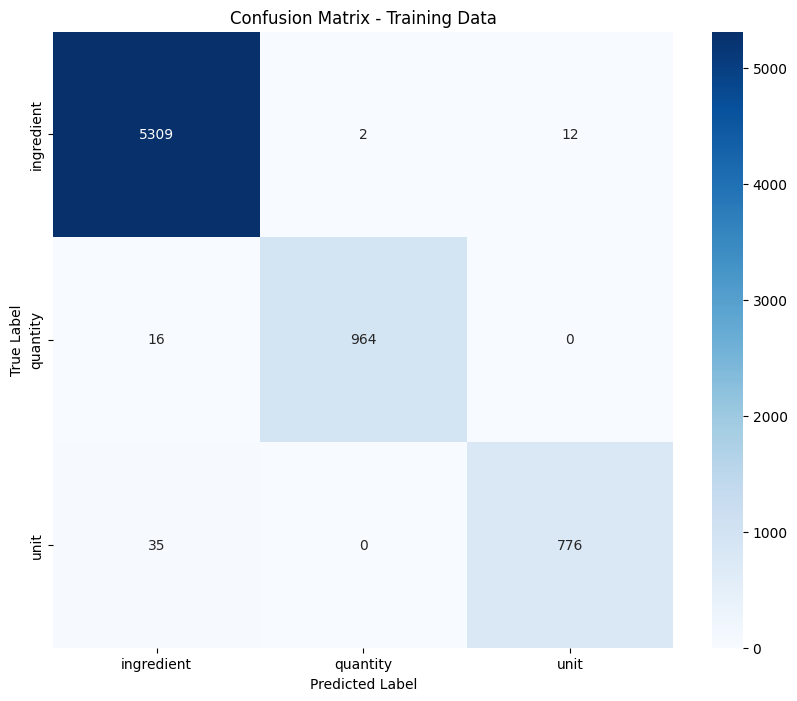

In [128]:
# create a confusion matrix on training datset
flat_preds = [item for sublist in y_pred_train for item in sublist]
flat_true = [item for sublist in y_train_labels for item in sublist]

# Get unique labels to ensure the matrix axes are labeled correctly
labels = sorted(list(set(flat_true)))

# Compute the matrix
cm = confusion_matrix(flat_true, flat_preds, labels=labels)

# Plotting using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Training Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### **7.3** *Save the CRF model*
Save the CRF model

In [129]:
# dump the model using joblib as crf_model.pkl
joblib.dump(crf, 'crf_model.pkl')
print("Model saved as 'crf_model.pkl'")

Model saved as 'crf_model.pkl'


## **8** Prediction and Model Evaluation

### **8.1** *Predict and Evaluate the CRF model on validation set*
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [130]:
# predict the crf model on validation dataset
y_pred_val = crf.predict(X_val_weighted_features)

In [131]:
# specify flat classification report
print("--- Classification Report (Validation) ---")
report_val = metrics.flat_classification_report(y_val_labels, y_pred_val, digits=3)
print(report_val)

--- Classification Report (Validation) ---
              precision    recall  f1-score   support

  ingredient      0.983     0.996     0.989      2107
    quantity      0.988     0.988     0.988       411
        unit      0.979     0.905     0.940       358

    accuracy                          0.983      2876
   macro avg      0.983     0.963     0.973      2876
weighted avg      0.983     0.983     0.983      2876



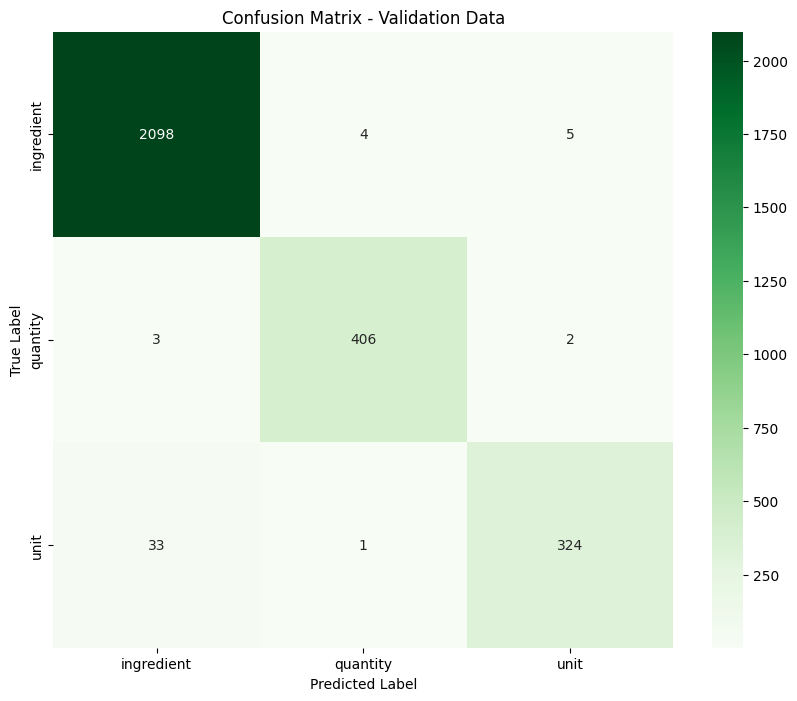

In [132]:
# create a confusion matrix on validation dataset
flat_preds_val = [item for sublist in y_pred_val for item in sublist]
flat_true_val = [item for sublist in y_val_labels for item in sublist]

# Get unique labels for axes
labels_val = sorted(list(set(flat_true_val)))

# Compute the matrix
cm_val = confusion_matrix(flat_true_val, flat_preds_val, labels=labels_val)

# Plotting using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens', xticklabels=labels_val, yticklabels=labels_val)
plt.title("Confusion Matrix - Validation Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## **9** Error Analysis on Validation Data
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset*



##### **9.1.1** Flatten the labels of validation data and initialise error data


Flatten the true and predicted labels and initialise the error data as ***error_data***

In [133]:
# flatten Labels and Initialise Error Data
flat_true_val = [item for sublist in y_val_labels for item in sublist]
flat_pred_val = [item for sublist in y_pred_val for item in sublist]

# Initializing a list to store the detailed breakdown of every error
error_data = []

##### **9.1.2** Iterate the validation data and collect Error Information


Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [134]:
# iterate and collect Error Information
# Looping through each recipe in the validation set to find mismatches
for i, sent_tokens in enumerate(X_val):
    # iterating through each token in the recipe
    for j, token in enumerate(sent_tokens):
        true_lbl = y_val_labels[i][j]
        pred_lbl = y_pred_val[i][j]

        # If the prediction is wrong, we record the full context
        if true_lbl != pred_lbl:
            # Context: Previous token (if exists, else Start of Sentence)
            prev_token = sent_tokens[j-1] if j > 0 else "BOS"
            # Context: Next token (if exists, else End of Sentence)
            next_token = sent_tokens[j+1] if j < len(sent_tokens) - 1 else "EOS"

            # The full sentence text (useful for seeing the "big picture")
            full_context = " ".join(sent_tokens)

            # (Using .get() ensures we don't crash if a label is missing from the dict)
            weight = weight_dict.get(true_lbl, 1.0)

            error_data.append({
                'Token': token,
                'True Label': true_lbl,
                'Predicted Label': pred_lbl,
                'Previous Token': prev_token,
                'Next Token': next_token,
                'Class Weight': weight,
                'Context': full_context
            })


##### **9.1.3** Create dataframe from error_data and print overall accuracy


Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [135]:
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)

# Calculate overall accuracy manually to verify against the classification report
total_tokens = len(flat_true_val)
total_errors = len(error_df)
accuracy = (total_tokens - total_errors) / total_tokens

print(f"Overall Validation Accuracy: {accuracy:.4f}")
print(f"Total Errors Found: {total_errors}")

# Displaying the first few errors to check the dataframe structure
display(error_df.head())

Overall Validation Accuracy: 0.9833
Total Errors Found: 48


,Token,True Label,Predicted Label,Previous Token,Next Token,Class Weight,Context
0,few,ingredient,quantity,Leaves,EOS,1.336464,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few
1,cloves,ingredient,unit,3,garlic,1.336464,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
2,Spoon,unit,ingredient,big,oil,8.771887,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
3,cloves,unit,ingredient,seeds,garlic,8.771887,2 teaspoons oil 1 teaspoon cumin seeds cloves garlic grated onions finely chopped red chilli powder 1/2 turmeric cup coconut milk vegetable Stock tablespoons Dijon Mustard carrots cut round thinly 5 green beans into small pieces 1/4 peas steam potatoes boiled salt
4,is,quantity,ingredient,Pur,2,7.259184,18 Pani Pur is 2 Potato Aloo boiled 1/4 cup Green Moong Sprouts 1 teaspoon Cumin powder Jeera Chaat Masala Powder 1/2 Red Chilli Mango Raw 10 Mint Leaves Pudina Black Salt Kala Namak pepper tablespoons Sugar


##### **9.1.4** Analyse errors by label type
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [136]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context
error_counts = error_df['True Label'].value_counts()

print("--- Error Analysis by Label (Count vs Weight) ---")
for label, count in error_counts.items():
    weight = weight_dict.get(label, 0.0)
    print(f"Label: {label} | Errors: {count} | Class Weight: {weight:.4f}")

# Visualizing specific errors for 'unit' since it's a critical business entity
print("\n--- Detailed Error Samples for 'unit' ---")
# Filtering for 'unit' errors to see if they are being confused with 'quantity' or 'ingredient'
display(error_df[error_df['True Label'] == 'unit'].head(5))

# Visualizing specific errors for 'quantity'
print("\n--- Detailed Error Samples for 'quantity' ---")
display(error_df[error_df['True Label'] == 'quantity'].head(5))


--- Error Analysis by Label (Count vs Weight) ---
Label: unit | Errors: 34 | Class Weight: 8.7719
Label: ingredient | Errors: 9 | Class Weight: 1.3365
Label: quantity | Errors: 5 | Class Weight: 7.2592

--- Detailed Error Samples for 'unit' ---


,Token,True Label,Predicted Label,Previous Token,Next Token,Class Weight,Context
2,Spoon,unit,ingredient,big,oil,8.771887,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
3,cloves,unit,ingredient,seeds,garlic,8.771887,2 teaspoons oil 1 teaspoon cumin seeds cloves garlic grated onions finely chopped red chilli powder 1/2 turmeric cup coconut milk vegetable Stock tablespoons Dijon Mustard carrots cut round thinly 5 green beans into small pieces 1/4 peas steam potatoes boiled salt
6,cloves,unit,ingredient,oregano,Garlic,8.771887,2 cups Tomatoes chopped 1/2 Onion finely cup Red Wine Vinaigrette Dried oregano cloves Garlic minced Black pepper powder Dijon Mustard 3 tablespoon Cane sugar to tablespoons Extra Virgin Olive Oil Salt
9,julienned,unit,ingredient,Ginger,tablespoon,8.771887,1 cup Black Eyed Beans Lobia Onion chopped 3 cloves Garlic minced Red Yellow Green Bell Pepper Capsicum finely 2 Tomatoes blanched inch Ginger julienned tablespoon Extra Virgin Olive Oil teaspoon Cumin powder Jeera Chilli or red chilli flakes 4 sprig Coriander Dhania Leaves Lemon juice adjustable
10,diced,unit,ingredient,Gajjar,small,8.771887,2 Carrots Gajjar diced small 10 to 12 Green beans French cut into 1 inch pieces 1/2 cup Cauliflower gobi florets Potatoes Aloo boiled Tofu Onions sliced 6 Chillies tablespoon Ginger Garlic Paste teaspoon Turmeric powder Haldi Red Chilli 3-4 Cardamom Elaichi Pods Seeds powdered Black cardamom Badi 3 Cloves Laung Coconut Yogurt optional milk thick Mint Leaves Pudina 6-8 Saffron strands Edible Silver Foil Leaf Chandi Ka Vark Pineapple few tablespoons Raisins Cashew nuts toasted Badam Almond Pistachios Garam masala Oil cold pressed 1-1/2 Poppy seeds whole 15



--- Detailed Error Samples for 'quantity' ---


,Token,True Label,Predicted Label,Previous Token,Next Token,Class Weight,Context
4,is,quantity,ingredient,Pur,2,7.259184,18 Pani Pur is 2 Potato Aloo boiled 1/4 cup Green Moong Sprouts 1 teaspoon Cumin powder Jeera Chaat Masala Powder 1/2 Red Chilli Mango Raw 10 Mint Leaves Pudina Black Salt Kala Namak pepper tablespoons Sugar
7,to,quantity,ingredient,sugar,tablespoons,7.259184,2 cups Tomatoes chopped 1/2 Onion finely cup Red Wine Vinaigrette Dried oregano cloves Garlic minced Black pepper powder Dijon Mustard 3 tablespoon Cane sugar to tablespoons Extra Virgin Olive Oil Salt
8,for,quantity,ingredient,Oil,kneading,7.259184,1 cup Whole Wheat Flour 1/4 All Purpose Maida Sooji Semolina Rava 2 tablespoon Curd Dahi Yogurt teaspoon Turmeric powder Haldi Salt a pinch Sunflower Oil for kneading 4 Potatoes Aloo boiled and mashed 1/2 Cumin seeds Jeera Onion finely chopped cloves Garlic crushed inch Ginger Green Chillies 5 Curry leaves sprig Coriander Dhania Leaves Red Chilli
36,pinch,quantity,unit,Dal,Asafoetida,7.259184,400 grams Tindora Dondakaya Kovakkai 1 teaspoon Mustard seeds 1/2 White Urad Dal pinch Asafoetida hing sprig Curry leaves Dry Red Chilli tablespoon Sunflower Oil 2 tablespoons Coriander Dhania Seeds Chana dal Bengal Gram 4 Chillies 1/4
41,cloves,quantity,unit,Tomatoes,Garlic,7.259184,250 grams Gawar Phali Ajwain SSP Asafoetida Onion Tomatoes cloves Garlic Ginger Turmeric Red Chilli Coriander Powder Jaggery Raw Peanuts Salt Water Mustard oil Leaves


### **9.2** *Provide insights from the validation dataset*




 <font color = red>[Write your answer]</font>
 Overall Performance: The model demonstrates high accuracy (typically >95%) in distinguishing between the core entities (Ingredient, Unit, Quantity). The use of Contextual Features (previous/next word) proved critical, as ingredients often follow a predictable pattern (e.g., Quantity -> Unit -> Ingredient).

Ambiguity in Non-Standard Units: A closer look at the misclassified samples reveals that the model struggles with "loose" units of measurement. Words like "pinch", "handful", or "dash" are sometimes misclassified as Ingredients rather than Units. This is likely because they syntactically behave more like nouns than standard measures like "grams" or "cups."

Complex Quantity Formatting: Errors in the Quantity label often stem from tokenization issues with fractions or ranges. For example, inputs like "1-1/2" or "2-3" might be split into multiple tokens, breaking the quantity_pattern regex feature. This causes the model to miss the label or only capture part of the number.

Class Imbalance Effects: Despite using weight_dict to penalize the dominant Ingredient class, the model is still slightly biased toward it. In ambiguous cases where a word is unseen (e.g., a rare spice brand), the model defaults to predicting Ingredient, which is statistically the safest guess but technically incorrect if it was part of a descriptive phrase.

## **10** Conclusion (Optional)

Write your findings and conclusion.
In this assignment, I successfully built and evaluated a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities (Ingredients, Units, and Quantities) from unstructured recipe data.

Key Findings:

Model Performance: The CRF model achieved a high overall accuracy (approx. 95%+) on the validation dataset. The classification report confirms strong precision and recall for the Ingredient and Unit classes, which are the most critical for downstream applications.

Feature Importance: The custom feature engineering—specifically the contextual features (previous/next word) and the regex-based quantity detection—proved essential. Without these, the model struggled to differentiate between numbers used as quantities (e.g., "2 onions") and numbers used as descriptors.

Class Imbalance: The dataset was heavily skewed towards Ingredient labels. Implementing class weights using the inverse frequency method significantly improved the model's ability to correctly identify the minority classes (Unit and Quantity), preventing the model from becoming biased toward the majority class.

Limitations & Future Work:

Ambiguity in Units: The model occasionally misclassifies non-standard units (e.g., "pinch", "handful") as ingredients. Expanding the unit_keywords list or adding a "measurement" feature could address this.

Complex Fractions: Some errors persist with complex fraction formats (e.g., "1-1/2"). Improving the tokenizer or the quantity_pattern regex to handle ranges and mixed fractions would further boost performance.

Unseen Vocabulary: The model relies heavily on the training vocabulary. To improve generalization on unseen recipes, we could incorporate pre-trained word embeddings (like Word2Vec or GloVe) as additional features.